


# **Q_4 Report, Ali Afshar Degarsi**




In [1]:
# set id of file
file_id ='1iXpovWmSrT3QeP0yqrhHClOkwowbUfy3'

In [2]:
# import downloader and download datas
!pip install gdown
import gdown

gdown.download(f'https://drive.google.com/uc?id={file_id}', 'APPL.csv', quiet=False)

Downloading...
From: https://drive.google.com/uc?id=1iXpovWmSrT3QeP0yqrhHClOkwowbUfy3
To: /content/APPL.csv
100%|██████████| 108k/108k [00:00<00:00, 5.76MB/s]


'APPL.csv'

In [3]:
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from torch.utils.data import DataLoader, TensorDataset
import os

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


In [4]:
df = pd.read_csv("APPL.csv")

In [5]:
data = df[['Close']].values

print(data)
print(f"minimum = {data.min()}")
print(f"maximum = {data.max()}")

[[ 79.01857 ]
 [ 77.28286 ]
 [ 77.704285]
 ...
 [235.869995]
 [235.320007]
 [234.369995]]
minimum = 71.397141
maximum = 236.210007


In [6]:
scaler = MinMaxScaler(feature_range=(0, 1))
data_scaled = scaler.fit_transform(data)

print(data)
print(f"minimum = {data_scaled.min()}")
print(f"maximum = {data_scaled.max()}")

[[ 79.01857 ]
 [ 77.28286 ]
 [ 77.704285]
 ...
 [235.869995]
 [235.320007]
 [234.369995]]
minimum = 0.0
maximum = 1.0


In [7]:
# define Sliding Window
X = []
y = []
window_size = 5

for i in range(len(data_scaled) - window_size):
    X.append(data_scaled[i:i+window_size, 0])
    y.append(data_scaled[i+window_size, 0])

X = np.array(X)
y = np.array(y)

# convert to pytorch tensors
X = torch.from_numpy(X).float()
y = torch.from_numpy(y).float()

# change shape for LSTM: (Batch Size, Sequence Length, Number of Features)
# here Sequence = 5 و Features = 1
X = X.view(-1, window_size, 1)

batch_size = 32
train_dataset = TensorDataset(X, y)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)


In [8]:
# ---------------------------------------------------------
# define LSTM
# ---------------------------------------------------------

class StockPriceLSTM(nn.Module):
    def __init__(self, input_size=1, hidden_layer_size=64, output_size=1):
        super().__init__()
        self.hidden_layer_size = hidden_layer_size

        self.lstm = nn.LSTM(input_size, hidden_layer_size, batch_first=True)

        self.linear = nn.Linear(hidden_layer_size, output_size)

    def forward(self, input_seq):
        lstm_out, _ = self.lstm(input_seq)

        last_time_step_out = lstm_out[:, -1, :]

        predictions = self.linear(last_time_step_out)
        return predictions

model = StockPriceLSTM().to(device)

In [9]:

learning_rate = 0.01
epochs = 30
loss_function = nn.MSELoss()  # Mean Squared Error
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

loss_history = []

print("Starting training...")

for epoch in range(epochs):
    model.train()
    epoch_loss = 0
    for batch_X, batch_y in train_loader:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)

        optimizer.zero_grad()
        y_pred = model(batch_X)
        loss = loss_function(y_pred, batch_y.unsqueeze(1)) # unsqueeze for matching dimensions
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()


    avg_epoch_loss = epoch_loss / len(train_loader)
    loss_history.append(avg_epoch_loss)

    print(f"Epoch {epoch+1}/{epochs} | Loss: {avg_epoch_loss:.6f}")

Starting training...
Epoch 1/30 | Loss: 0.030990
Epoch 2/30 | Loss: 0.000585
Epoch 3/30 | Loss: 0.000393
Epoch 4/30 | Loss: 0.000414
Epoch 5/30 | Loss: 0.000457
Epoch 6/30 | Loss: 0.000438
Epoch 7/30 | Loss: 0.000397
Epoch 8/30 | Loss: 0.000393
Epoch 9/30 | Loss: 0.000542
Epoch 10/30 | Loss: 0.000407
Epoch 11/30 | Loss: 0.000378
Epoch 12/30 | Loss: 0.000403
Epoch 13/30 | Loss: 0.000542
Epoch 14/30 | Loss: 0.000428
Epoch 15/30 | Loss: 0.000353
Epoch 16/30 | Loss: 0.000447
Epoch 17/30 | Loss: 0.000412
Epoch 18/30 | Loss: 0.000300
Epoch 19/30 | Loss: 0.000293
Epoch 20/30 | Loss: 0.000300
Epoch 21/30 | Loss: 0.000395
Epoch 22/30 | Loss: 0.000301
Epoch 23/30 | Loss: 0.000296
Epoch 24/30 | Loss: 0.000280
Epoch 25/30 | Loss: 0.000311
Epoch 26/30 | Loss: 0.000286
Epoch 27/30 | Loss: 0.000315
Epoch 28/30 | Loss: 0.000274
Epoch 29/30 | Loss: 0.000367
Epoch 30/30 | Loss: 0.000256



1) Model Architecture Report:
StockPriceLSTM(
  (lstm): LSTM(1, 64, batch_first=True)
  (linear): Linear(in_features=64, out_features=1, bias=True)
)

Total number of trainable parameters: 17217
2) Activation Functions:
   - LSTM Layer: Sigmoid and Tanh 
   - Output Layer: Linear (without activation function for regression)
3) Number of Epochs: 30
4) Loss Function: MSELoss
 Final Value of Loss: 0.000256


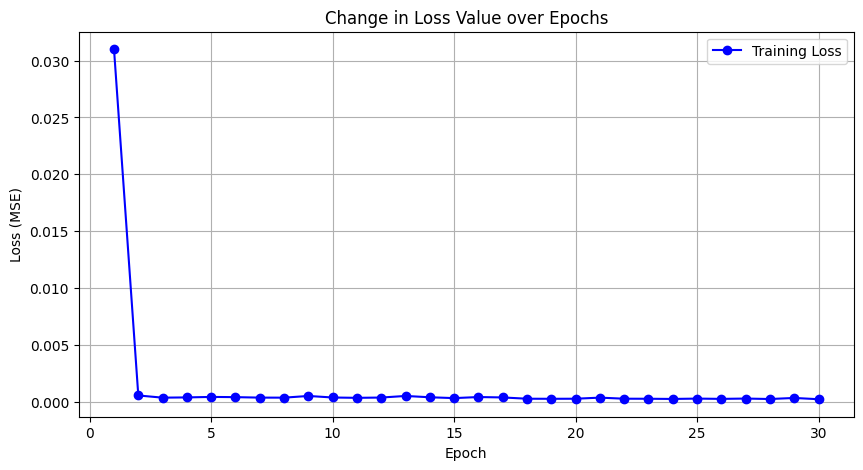

In [14]:
# ---------------------------------------------------------
# گزارش نهایی و نمودار
# ---------------------------------------------------------

# 1) تعداد لایه‌ها و تعداد نورون‌های هر لایه
print("\n" + "="*30)
print("1) Model Architecture Report:")
print("="*30)
print(model)

# محاسبه تعداد کل پارامترها
total_params = sum(p.numel() for p in model.parameters())
print(f"\nTotal number of trainable parameters: {total_params}")

# 2) تابع فعالسازی مورد استفاده
print("2) Activation Functions:")
print("   - LSTM Layer: Sigmoid and Tanh ")
print("   - Output Layer: Linear (without activation function for regression)")

# 3) تعداد دوره‌های آموزشی
print(f"3) Number of Epochs: {epochs}")

# 4) تابع هزینه و مقدار نهایی آن
final_loss = loss_history[-1]
print(f"4) Loss Function: MSELoss")
print(f" Final Value of Loss: {final_loss:.6f}")

# 5) نمودار تغییرات Loss
plt.figure(figsize=(10, 5))
plt.plot(range(1, epochs+1), loss_history, marker='o', color='b', label='Training Loss')
plt.title('Change in Loss Value over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.grid(True)
plt.legend()
plt.show()